# Proyecto Unidad 4: Modelado y predicción con Python
---

## Descripción del proyecto
La empresa ***MusicStat Insights*** trabaja en el análisis de la industria musical, con alianzas en la producción y distribución musical, entre las que destaca su trabajo para Spotify, que le ha permitido adquirir metadatos sobre las canciones publicadas en la plataforma.
UItilizando el dataset `spotify_tracks.csv`, se quiere:

1.	Predecir la popularidad de los temas en base a sus metadatos para extraer conocimiento del mercado musical.

2.	Automatizar la clasificación de los temas en géneros musicales basándose en sus características acústicas.

---


In [2]:
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
from sklearn.model_selection import cross_val_score
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score)
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier


## Fase 1: Análisis preliminar

### Apartado 1: Información básica del dataset

1.1. Cargar el dataset spotify_tracks.csv

1.2. Mostrar las dimensiones del dataset (filas y columnas)

1.3. Listar los nombres de todas las columnas

In [3]:
# Apartado 1.1
df = pd.read_csv("spotify_tracks.csv")
print(df.head())

print()

# Apartado 1.2
print("Dimensiones del dataset:")
print(df.shape)
print(f"Filas: {df.shape[0]}")
print(f"Columnas: {df.shape[1]}")
print()

# Apartado 1.3
print("Columnas del dataset:")

for columna in df.columns:
  print(columna)


                 track_id                 artists  \
0  5SuOikwiRyPMVoIQDJUgSV             Gen Hoshino   
1  4qPNDBW1i3p13qLCt0Ki3A            Ben Woodward   
2  1iJBSr7s7jYXzM8EGcbK5b  Ingrid Michaelson;ZAYN   
3  6lfxq3CG4xtTiEg7opyCyx            Kina Grannis   
4  5vjLSffimiIP26QG5WcN2K        Chord Overstreet   

                                          album_name  \
0                                             Comedy   
1                                   Ghost (Acoustic)   
2                                     To Begin Again   
3  Crazy Rich Asians (Original Motion Picture Sou...   
4                                            Hold On   

                   track_name  popularity  duration_ms  explicit  \
0                      Comedy          73       230666     False   
1            Ghost - Acoustic          55       149610     False   
2              To Begin Again          57       210826     False   
3  Can't Help Falling In Love          71       201933     False   
4   

### Apartado 2: Separación de variables

2.1. Identifica y divide en el DataFrames las variables (`X`) de las columnas objetivo, tanto para la predicción de popularidad (`y_regression`) como para la clasificación de géneros musicales (`y_clasification`).

2.2. Identifica y guarda en listas separadas los nombres de las variables textuales (`textual_cols`), las numéricas (`numeric_cols`) y las booleanas (`boolean_cols`).

In [4]:
# Apartado 2.1

# Predicción de popularidad, numérica
y_regression = df["popularity"]

# Predicción de clasificación, categórica
y_classification = df["track_genre"]

# Variables predictoras
X = df.drop(columns=["popularity", "track_genre"])

print()

# Apartado 2.2

# 1- Textuales
textual_cols = X.select_dtypes(include=["object"]).columns.tolist()

# 2- Numéricas
numeric_cols = X.select_dtypes(include=["int64", "float64"]).columns.tolist()

# 3 Booleanas
boolean_cols = X.select_dtypes(include=["bool"]).columns.tolist()


# Mantener solo variables numéricas porque
# modelos LinearRegression, Ridge y Lasso
# solo trabajan con números (float o int).
cols_modelo = numeric_cols + boolean_cols
X = X[cols_modelo]

# 4- Comprobar que ya no hay texto
print(X.dtypes)
print(X.select_dtypes(include=["object"]).columns.tolist())

print("Columnas textuales:")
print(textual_cols)
print()

print("Columnas numéricas:")
print(numeric_cols)
print()

print("Columnas booleanas:")
print(boolean_cols)
print()


duration_ms           int64
danceability        float64
energy              float64
key                   int64
loudness            float64
mode                  int64
speechiness         float64
acousticness        float64
instrumentalness    float64
liveness            float64
valence             float64
tempo               float64
time_signature        int64
explicit               bool
dtype: object
[]
Columnas textuales:
['track_id', 'artists', 'album_name', 'track_name']

Columnas numéricas:
['duration_ms', 'danceability', 'energy', 'key', 'loudness', 'mode', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo', 'time_signature']

Columnas booleanas:
['explicit']



### Apartado 3: Limpieza y normalización

3.1. Elimina las columnas que puedan llevar a un sobreajuste de los modelos (`track_id`, `artists`, `album_name` y `track_name`).

3.2. Convertir las columnas booleanas a numéricas (0 y 1).

3.3. Normaliza entre 0 y 1 las variables numéricas utilizando `MinMaxScaler`.


In [6]:
# Apartado 3.1
# Todas las columnas textuales de este proyecto pueden llevar a sobreajuste, ya que tienen +30.000 valores diferentes
# Eliminación de columnas y uso del "errors="ignore" caso las columnas no existan
X = X.drop(columns=["track_id", "artists", "album_name", "track_name"], errors="ignore")

# Apartado 3.2
# Columnas booleanas a númericas
for col in boolean_cols:
  X[col] = X[col].astype(int)

# Apartado 3.3
# Uso del escalador con MinMaxScaler
scaler = MinMaxScaler()

# Normalización de variables numéricas entre 0 y 1
# usando los valores mínimos y máximos de cada columna con MinMaxScaler
X[numeric_cols] = scaler.fit_transform(X[numeric_cols])
print(X.head())

   duration_ms  danceability  energy       key  loudness  mode  speechiness  \
0     0.044043      0.686294  0.4610  0.090909  0.791392   0.0     0.148187   
1     0.028566      0.426396  0.1660  0.090909  0.597377   1.0     0.079067   
2     0.040255      0.444670  0.3590  0.000000  0.736123   1.0     0.057720   
3     0.038557      0.270051  0.0596  0.000000  0.573701   1.0     0.037617   
4     0.037969      0.627411  0.4430  0.181818  0.737103   1.0     0.054508   

   acousticness  instrumentalness  liveness   valence     tempo  \
0      0.032329          0.000001    0.3580  0.718593  0.361245   
1      0.927711          0.000006    0.1010  0.268342  0.318397   
2      0.210843          0.000000    0.1170  0.120603  0.313643   
3      0.908635          0.000071    0.1320  0.143719  0.746758   
4      0.470884          0.000000    0.0829  0.167839  0.492863   

   time_signature  explicit  
0             0.8         0  
1             0.8         0  
2             0.8         0  
3 

### Apartado 4: Estadísticas descriptivas

4.1. Mostrar las estadísticas descriptivas básicas de todas las columnas numéricas.

4.2. Identificar los tipos de datos de las variables objetivo. Si son numéricas, imprime su descriptivo y, en caso contrario, su distribución de frecuencia.

4.3. Representa la distribución de valores de la popularidad en un histograma.

4.4. Representa la distribución de frecuencia de los géneros musicales en un diagrama de barras.


In [7]:
# Apartado 4.1
print("Estadísticas descriptivas: columnas numéricas")
print(df.describe())

Estadísticas descriptivas: columnas numéricas
          popularity   duration_ms   danceability         energy  \
count  114000.000000  1.140000e+05  114000.000000  114000.000000   
mean       33.238535  2.280292e+05       0.566800       0.641383   
std        22.305078  1.072977e+05       0.173542       0.251529   
min         0.000000  0.000000e+00       0.000000       0.000000   
25%        17.000000  1.740660e+05       0.456000       0.472000   
50%        35.000000  2.129060e+05       0.580000       0.685000   
75%        50.000000  2.615060e+05       0.695000       0.854000   
max       100.000000  5.237295e+06       0.985000       1.000000   

                 key       loudness           mode    speechiness  \
count  114000.000000  114000.000000  114000.000000  114000.000000   
mean        5.309140      -8.258960       0.637553       0.084652   
std         3.559987       5.029337       0.480709       0.105732   
min         0.000000     -49.531000       0.000000       0.000000

In [8]:
# Apartado 4.2
print("Tipo de dato de y_regression:")
print(y_regression.dtype)
print()
print("Tipo de dato de y_classification:")
print(y_classification.dtype)
print()

# Estadísticas de popularity
print("Descriptivo de popularity:")
print(y_regression.describe())
print()

#Frecuencias de generos musicales
print("Frecuencia de géneros musicales:")
print(y_classification.value_counts())

Tipo de dato de y_regression:
int64

Tipo de dato de y_classification:
object

Descriptivo de popularity:
count    114000.000000
mean         33.238535
std          22.305078
min           0.000000
25%          17.000000
50%          35.000000
75%          50.000000
max         100.000000
Name: popularity, dtype: float64

Frecuencia de géneros musicales:
track_genre
traditional_roots    26000
electronic           25000
rock_metal           23000
vibe                 19000
latino               11000
modern               10000
Name: count, dtype: int64


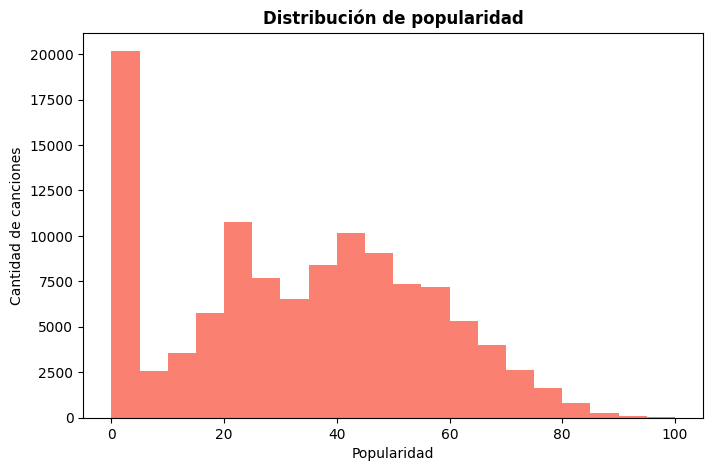

In [9]:
# Apartado 4.3
# Histograma de popularidad

plt.figure(figsize=(8,5))

plt.hist(y_regression, bins=20, color="salmon")

plt.title("Distribución de popularidad", fontweight='bold')
plt.xlabel("Popularidad")
plt.ylabel("Cantidad de canciones")

plt.show()


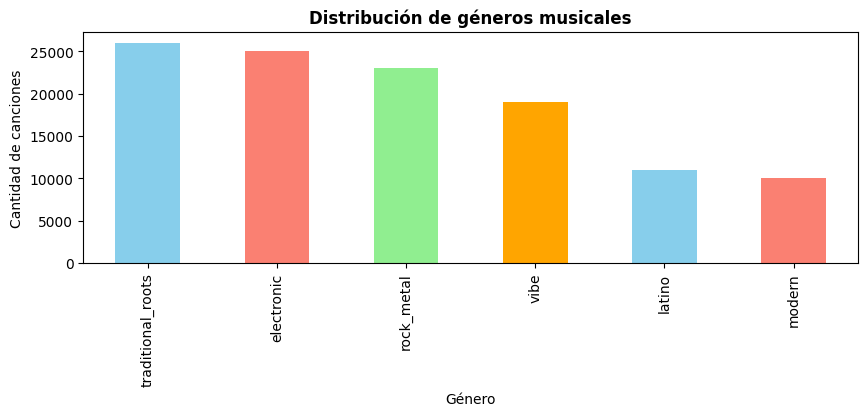

In [10]:
# Apartado 4.4
# Diagrama de barras de géneros musicales

conteo_generos = y_classification.value_counts()

plt.figure(figsize=(10,3))
conteo_generos.plot(kind="bar", color=["skyblue", "salmon", "lightgreen", "orange"])
plt.title("Distribución de géneros musicales", fontweight='bold')
plt.xlabel("Género")
plt.ylabel("Cantidad de canciones")
plt.show()


---
## Fase 2: Modelado de Regresión (Predicción de popularidad)
### Apartado 5: División de datos de entrenamiento y prueba

5.1. Dividir el conjunto de datos de entrenamiento y prueba en 80/20 fijando como semilla de aleatoriedad 74. Mantén la proporcionalidad de la popularidad en ambos conjuntos utilizando el parámetro `stratify=pd.cut(y_regression,bins=20,labels=False)`.

5.2. Si durante la evaluación de un modelo observamos que al cambiar la semilla, el rendimiento del modelo cambia varía mucho, ¿qué puede estar ocurriendo?

In [32]:
# Apartado 5.1
# Dividimos los datos en entrenamiento con 80% y prueba 20%

# X, variables predictoras
# X_train, variables de entrenamiento
# X_test, variables de prueba
# y_train, resultados reales para entrenamiento
# y_test, resultados reales para prueba
# y_regression, popularity
# test_size=0.2, 20% prueba, 80% entrenamiento
# random_state=74, divisi'on de los datos siempre la misma
# stratify=pd.cut(y_regression, bins=20, labels=False), distribución equilibrada de la popularidad
# con valores en 20 grupos

X_train, X_test, y_train, y_test = train_test_split(
  X,
  y_regression,
  test_size=0.2,
  random_state=74,
  stratify=pd.cut(y_regression, bins=20, labels=False)
  )

# Mostramos el tamaño de cada conjunto
print("Tamaño de entrenamiento:")
print(X_train.shape)
print(X_train.head())
print()

print("Tamaño de prueba:")
print(X_test.shape)

Tamaño de entrenamiento:
(91200, 14)
       duration_ms  danceability  energy       key  loudness  mode  \
16800     0.107478      0.422335  0.0952  0.909091  0.439302   1.0   
74250     0.039813      0.449746  0.6850  0.818182  0.802619   1.0   
21519     0.037153      0.588832  0.7480  0.636364  0.797921   1.0   
30066     0.013748      0.350254  0.6800  0.181818  0.719364   1.0   
92074     0.023572      0.640609  0.5690  0.454545  0.806004   0.0   

       speechiness  acousticness  instrumentalness  liveness   valence  \
16800     0.041762      0.995984          0.905000     0.113  0.348744   
74250     0.032332      0.351406          0.000006     0.118  0.649246   
21519     0.309845      0.275100          0.000000     0.127  0.943719   
30066     0.029845      0.575301          0.984000     0.192  0.151759   
92074     0.045389      0.730924          0.000000     0.270  0.878392   

          tempo  time_signature  explicit  
16800  0.462695             0.8         0  
74250  0.

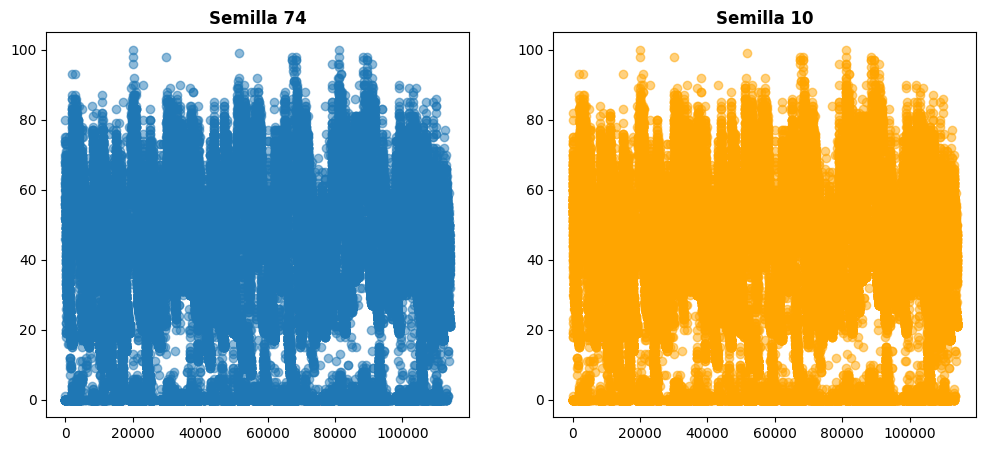

In [33]:
# División con semilla 74
X_train_74, X_test_74, y_train_74, y_test_74 = train_test_split(
  X,
  y_regression,
  test_size=0.2,
  random_state=74
)

# División con semilla 10
X_train_10, X_test_10, y_train_10, y_test_10 = train_test_split(
  X,
  y_regression,
  test_size=0.2,
  random_state=10
)

# Gráficos

# Semilla 74
fig, axes = plt.subplots(1, 2, figsize=(12,5))

axes[0].scatter(
  X_train_74.index,
  y_train_74,
  alpha=0.5
)

# Semilla 10
axes[0].set_title("Semilla 74", fontweight='bold')

axes[1].scatter(
  X_train_10.index,
  y_train_10,
  alpha=0.5,
  color="orange"
)

axes[1].set_title("Semilla 10", fontweight='bold')

plt.show()

### Apartado 5.2
He hecho pruebas cambiando el valor de la semilla y he podido ver que, aunque el tamaño de los conjuntos sigue siendo el mismo, las filas que se reparten entre entrenamiento y prueba cambian.

Esto puede significar que el modelo depende bastante de cómo se dividen los datos. Por eso, considero que el modelo no es del todo estable y que sería recomendable evaluarlo mejor utilizando técnicas como la validación cruzada.

In [ ]:
# Resultados con la validación cruzada

# Creamos 1º los modelos
# Modelos
modelo_simple = LinearRegression()
modelo_multiple = LinearRegression()
modelo_rf = RandomForestRegressor(
    n_estimators=100,
    random_state=74
)

scores_simple = cross_val_score(
  modelo_simple,
  X_train_simple,
  y_train,
  cv=5,
  scoring="r2"
)


scores_multiple = cross_val_score(
  modelo_multiple,
  X_train,
  y_train,
  cv=5,
  scoring="r2"
)

scores_rf = cross_val_score(
  modelo_rf,
  X_train,
  y_train,
  cv=5,
  scoring="r2"
)

# Gráfico
plt.figure(figsize=(10,5))

plt.plot(
  range(1,6),
  scores_simple,
  marker="o",
  label="Lineal Simple"
)

plt.plot(
  range(1,6),
  scores_multiple,
  marker="o",
  label="Lineal Múltiple"
)

plt.plot(
  range(1,6),
  scores_rf,
  marker="o",
  label="Random Forest"
)

plt.title("Validación cruzada (R2)", fontweight='bold')
plt.xlabel("Fold")
plt.ylabel("R2")
plt.legend()
plt.grid(True)
plt.show()


########################################################
# Prueba con parametros, configurraciones alterados
########################################################
# Evitar que cross_val_score estea entrenando con
# demasiadas filas y muchas columnas y a'si la prubea
# sea mas rapida

# Parámetros/configuraciones del modelo y de la validación.
# paramentros_ n_estimators=5
# max_depth=10
# cv=3
# sample(n=10000)

# Creamos 1º los modelos
# Modelos
# modelo_simple = LinearRegression()
# modelo_multiple = LinearRegression()

# modelo_rf = RandomForestRegressor(
#     n_estimators=5,
#     max_depth=10,
#     random_state=74,
#     n_jobs=-1
#)

# Muestra pequeña para acelerar
# X_train_muestra = X_train.sample(n=10000, random_state=74)
# y_train_muestra = y_train.loc[X_train_muestra.index]

# Modelo simple con una sola variable
# X_train_simple = X_train_muestra[["energy"]]

# Validación cruzada
# scores_simple = cross_val_score(
#     modelo_simple,
#     X_train_simple,
#     y_train_muestra,
#     cv=3,
#     scoring="r2"
# )

# scores_multiple = cross_val_score(
#     modelo_multiple,
#     X_train_muestra,
#     y_train_muestra,
#     cv=3,
#     scoring="r2"
# )

# scores_rf = cross_val_score(
#     modelo_rf,
#     X_train_muestra,
#     y_train_muestra,
#     cv=3,
#     scoring="r2"
# )

# Resultados
# print("R2 modelo simple:", scores_simple)
# print("Media R2 simple:", scores_simple.mean())
# print()

# print("R2 modelo múltiple:", scores_multiple)
# print("Media R2 múltiple:", scores_multiple.mean())
# print()

# print("R2 Random Forest:", scores_rf)
#print("Media R2 Random Forest:", scores_rf.mean())

# Gráfico
# plt.figure(figsize=(10,5))

# plt.plot(range(1,4), scores_simple, marker="o", label="Lineal Simple")
# plt.plot(range(1,4), scores_multiple, marker="o", label="Lineal Múltiple")
# plt.plot(range(1,4), scores_rf, marker="o", label="Random Forest")

# plt.title("Validación cruzada rápida (R2)", fontweight="bold")
# plt.xlabel("Fold")
# plt.ylabel("R2")
# plt.legend()
# plt.grid(True)
# plt.show()

### Apartado 6: Análisis de correlación

6.1. Calcular y representar la matriz de correlación de las variables numéricas

6.2. Calcula las correlaciones entre las variables y la columna popularity. Ordena las correlaciones y muestra las 5 variables que mayor correlación tienen junto con el valor numérico.

6.3. ¿Cómo crees que será el rendimiento de un modelo predictivo lineal? ¿Por qué?


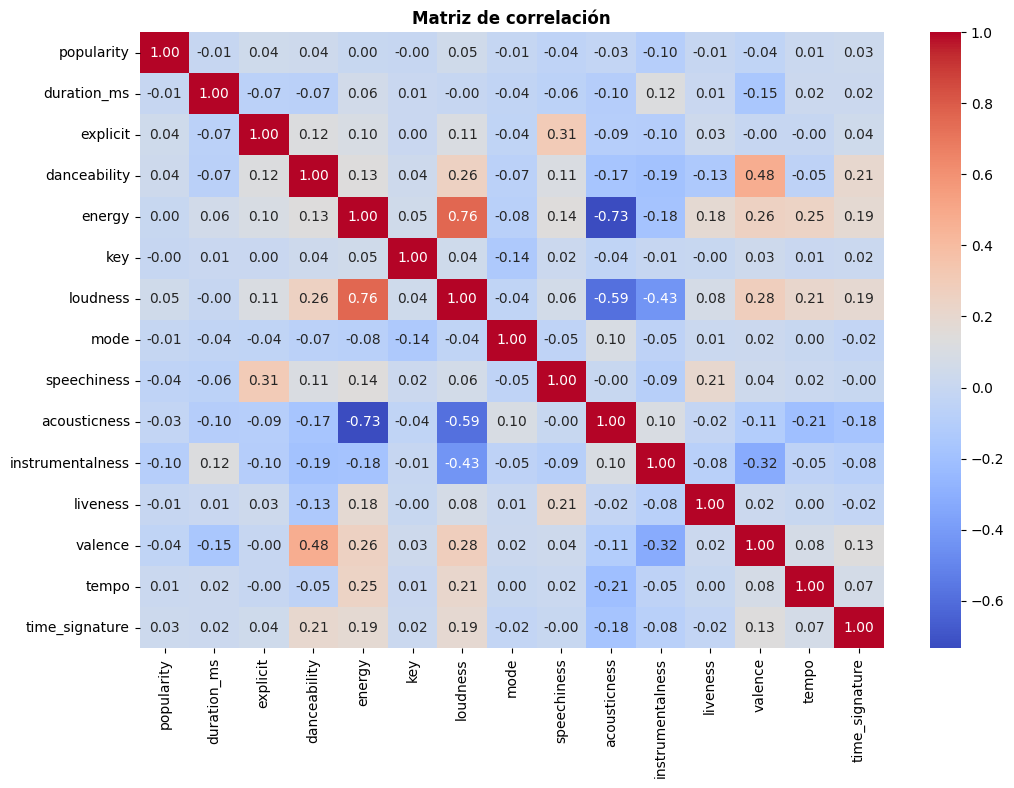

In [15]:
# Apartado 6.1
# Matriz de correlación de las variables numéricas
matriz_correlacion = df.corr(numeric_only=True)

plt.figure(figsize=(12,8))

sns.heatmap(matriz_correlacion, annot=True, cmap="coolwarm",fmt=".2f")
plt.title("Matriz de correlación", fontweight='bold')
plt.show()

In [16]:
# Apartado 6.2
correlacion_popularity = matriz_correlacion["popularity"]
correlacion_popularity = correlacion_popularity.sort_values(ascending=False)

print("Variables con mayor correlación con popularity:")
print(correlacion_popularity.head(6))

Variables con mayor correlación con popularity:
popularity        1.000000
loudness          0.050423
explicit          0.044082
danceability      0.035448
time_signature    0.031073
tempo             0.013205
Name: popularity, dtype: float64


### Apartado 6.3
Una vez analisado el comportamento de la matriz de correlación, creo que un modelo lineal podría tener un rendimiento aceptable, aún que no demasiado alto.

Se nota en el gráfico que la mayoría de variables tienen correlaciones bastante bajas con "popularity", una relación entre las características de las canciones y su popularidad no es completamente lineal.

### Apartado 7: Entrenamiento
7.1. Entrenar un modelo de Regresión Lineal Simple utilizando únicamente la variable con mayor correlación con la columna objetivo (la encontrada en el apartado 6.2)

7.2. Entrenar un modelo de Regresión Lineal Múltiple utilizando todas las variables disponibles.

7.3. Entrena un modelo Random Forest Regressor utilizando todas las variables disponibles. Utiliza para ello los parámetros `n_estimators=10` y `random_state=74`.



In [22]:
# Apartado 7.1
mejor_variable = correlacion_popularity.drop("popularity").idxmax()

print("Variable con mayor correlación:")
print(mejor_variable)
print()

# Conjunto de datos con la mejor variable
X_train_simple = X_train[[mejor_variable]]
X_test_simple = X_test[[mejor_variable]]


#modelo_simple = LinearRegression()
# Se ha comentado modelo_multiple = LinearRegression()
# ya q fue creado en el apartado 5.2
# Se entreina el modelo
modelo_simple.fit(X_train_simple, y_train)

Variable con mayor correlación:
loudness



LinearRegression()

In [23]:
# Apartado 7.2
#modelo_multiple = LinearRegression()
modelo_multiple.fit(X_train, y_train)

print("Modelo de regresión lineal múltiple entrenado")


Modelo de regresión lineal múltiple entrenado


In [24]:
# Apartado 7.3
#modelo_rf = RandomForestRegressor(n_estimators=10, random_state=74)
modelo_rf.fit(X_train, y_train)

print("Modelo Random Forest entrenado")

Modelo Random Forest entrenado


### Apartado 8: Comparativa de rendimiento

8.1. Calcular las métricas de MAE, MSE, RMSE y R2 para los modelos entrenados en el apartado anterior sobre el conjunto de test.

8.2. Para asegurar que los resultados no dependen de una división aleatoria de los datos, utiliza `cross_val_score` con los tres modelos entrenados, con `cv=5` y optimizando R2. Calcula y muestra la media y desviación típica de los resultados de cada modelo.

8.3. Interpretación: ¿Cúál de los modelos ha obtenido mejor rendimiento? Justifica si el incremento de complejidad de cada modelo merece la pena.

8.4. Propón, sin implementar, alguna mejora para incrementar el rendimiento de la predicción.


In [ ]:
# Apartado 8.1

pred_simple = modelo_simple.predict(X_test_simple)
pred_multiple = modelo_multiple.predict(X_test)
pred_rf = modelo_rf.predict(X_test)

print("Regresión Lineal Simple")

mae = mean_absolute_error(y_test, pred_simple)
mse = mean_squared_error(y_test, pred_simple)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, pred_simple)

print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R2:", r2)

print()
print("Regresión Lineal Múltiple")

mae = mean_absolute_error(y_test, pred_multiple)
mse = mean_squared_error(y_test, pred_multiple)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, pred_multiple)

print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R2:", r2)


print()
print("Random Forest Regressor")

mae = mean_absolute_error(y_test, pred_rf)
mse = mean_squared_error(y_test, pred_rf)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, pred_rf)

print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R2:", r2)

In [26]:
# Apartado 8.2

# Regresión Lineal Simple
scores_simple = cross_val_score(
    modelo_simple,
    X_train_simple,
    y_train,
    cv=5,
    scoring="r2"
)

print("Regresión Lineal Simple:")
print("Media R2:", scores_simple.mean())
print("Desviación típica:", scores_simple.std())

print()
# Regresión Lineal Múltiple
scores_multiple = cross_val_score(
    modelo_multiple,
    X_train,
    y_train,
    cv=5,
    scoring="r2"
)

print("Regresión Lineal Múltiple")
print("Media R2:", scores_multiple.mean())
print("Desviación típica:", scores_multiple.std())

print()
# Random Forest
scores_rf = cross_val_score(
    modelo_rf,
    X_train,
    y_train,
    cv=5,
    scoring="r2"
)

print("Random Forest Regressor:")
print("Media R2:", scores_rf.mean())
print("Desviación típica:", scores_rf.std())

Regresión Lineal Simple:
Media R2: 0.002419134690285074
Desviación típica: 0.0005141162077050741

Regresión Lineal Múltiple
Media R2: 0.02483231110638735
Desviación típica: 0.002098115732353813



KeyboardInterrupt: 

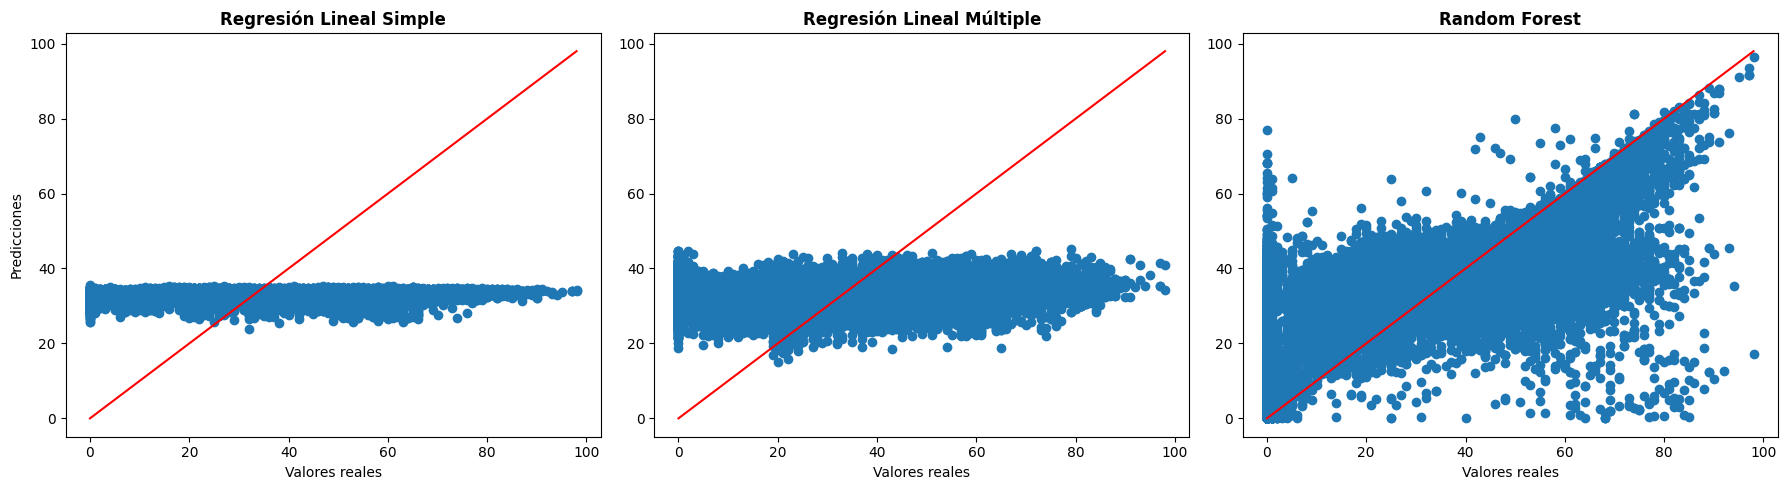

In [27]:
# Gráficos para comprar valores reales vs predicciones

pred_simple = modelo_simple.predict(X_test_simple)
pred_multiple = modelo_multiple.predict(X_test)
pred_rf = modelo_rf.predict(X_test)

fig, axes = plt.subplots(1, 3, figsize=(18,5))


# Regresión lineal simple
axes[0].scatter(y_test, pred_simple)
axes[0].plot(
  [y_test.min(), y_test.max()],
  [y_test.min(), y_test.max()],
  color="red"
)

axes[0].set_title("Regresión Lineal Simple", fontweight='bold')
axes[0].set_xlabel("Valores reales")
axes[0].set_ylabel("Predicciones")

# Regresión lineal múltiple
axes[1].scatter(y_test, pred_multiple)
axes[1].plot(
  [y_test.min(), y_test.max()],
  [y_test.min(), y_test.max()],
  color="red"
)

axes[1].set_title("Regresión Lineal Múltiple", fontweight='bold')
axes[1].set_xlabel("Valores reales")


# Random Forest
axes[2].scatter(y_test, pred_rf)
axes[2].plot(
  [y_test.min(), y_test.max()],
  [y_test.min(), y_test.max()],
  color="red"
)

axes[2].set_title("Random Forest", fontweight='bold')
axes[2].set_xlabel("Valores reales")

plt.tight_layout()
plt.show()

### Apartado 8.3
Después de comparar los resultados, he podido ver claramente que el modelo que mejor rendimiento obtiene es Random Forest Regressor.

Esto se puede observar en el valor de R2, ya que cuanto más cerca esté de 1, mejor es el rendimiento del modelo. En este caso, Random Forest obtuvo un R2 de 0.448, bastante superior al de los modelos lineales.

La regresión lineal simple prácticamente no consigue explicar la popularidad de las canciones, ya que su valor de R2 es muy cercano a 0. La regresión lineal múltiple mejora un poco, aunque sigue teniendo un rendimiento bastante bajo.

Además, la desviación típica de Random Forest es 0.0079, un valor bastante pequeño, lo que indica que el modelo también es bastante estable y mantiene resultados similares en las diferentes particiones de la validación cruzada.

Por eso, considero que el aumento de complejidad sí merece la pena, ya que la mejora del rendimiento respecto a los modelos lineales es bastante grande.

### Apartado 8.4
Creo que una posible mejora sería probar más configuraciones en Random Forest, por ejemplo aumentando el número de árboles o cambiando algunos parámetros para intentar mejorar las predicciones.

También podría ayudar eliminar variables que no aporten demasiado o probar otros modelos más avanzados que puedan adaptarse mejor a los datos.

---
## Fase 4: Modelado de clasificación (Identificación de Géneros)

### Apartado 9: Clasificación de Géneros

9.1. Dividir el conjunto de datos de entrenamiento y prueba en 80/20 fijando como semilla de aleatoriedad 74. Mantén la proporcionalidad de los géneros en ambos conjuntos.

9.2. Entrenar un modelo Support Vector Machine (SVN) para la predicción de `track_genre`.

9.3. Entrenar un modelo Random Forest sobre los mismos datos.


In [28]:
# Apartado 9.1
X_train_class, X_test_class, y_train_class, y_test_class = train_test_split(
  X,
  y_classification,
  # 80% entrenamiento y 20% prueba
  test_size=0.2,
  random_state=74,
  stratify=y_classification
)

# Mostramos los tamaños
print("Tamaño entrenamiento:")
print(X_train_class.shape)

print()

print("Tamaño prueba:")
print(X_test_class.shape)



Tamaño entrenamiento:
(91200, 14)

Tamaño prueba:
(22800, 14)


In [29]:
# Apartado 9.2
#Se crea el modelo Support Vector Machine (SVN)
modelo_svm = SVC()

# Entrenamos el modelo con los datos de entrenamiento
modelo_svm.fit(X_train_class, y_train_class)
print("Modelo SVM entrenado correctamente")


Modelo SVM entrenado correctamente


In [39]:
# Apartado 9.3

# Creamos el modelo Random Forest con sus número de árboles y semilla aleatoria
modelo_rf_class = RandomForestClassifier( n_estimators=10, random_state=74)

# Entrenamos el modelo
modelo_rf_class.fit(X_train_class, y_train_class)
print("Modelo Random Forest entrenado ")


Modelo Random Forest entrenado 


### Apartado 10: Evaluación de la clasificación

10.1. Calcula, para cada uno de los modelos anteriores, los valores de precision, accuracy, recall y F1-score (macro) y muéstralos por pantalla.

10.2. Calcula las métricas micro para cada una de las categorías de la clasificación (precision, recall y F1-score). Muéstralas por pantalla.

10.3. Si un modelo clasificador tiene unas métricas macro extraordinariamente buenas (+97%), y una elevada varianza en las métricas micro:

- a)	Es un buen clasificador, ya que las métricas macro son las que reflejan todas las categorías en conjunto.
- b)	Tengo que mejorar las métricas micro, pero debo quedarme siempre con el modelo que mejores métricas macro tenga, ya que reflejan el rendimiento general del modelo.
- c)	Tengo que equilibrar las métricas micro. El mejor modelo será el que mejor rendimiento tenga con las medidas micro equilibradas.
- d)	Las métricas micro solo son importantes para detección de anomalías, donde se miden las métricas de la detección, pero en clasificadores multiclase debemos priorizar siempre las métricas macro.

10.4. Utiliza la función `classification_report` (disponible en `sklearn.metrics`) e imprime por pantalla el resultado. Concuerda con los obtenidos en los apartados 10.1 y 10.2?

10.5. Mostrar las matrices de confusión de ambos modelos clasificadores.

10.6. ¿Hay géneros que el modelo confunda habitualmente entre sí? ¿A qué crees que se debe? Interpreta los resultados de ambos clasificadores en base a sus métricas y matrices de confusión.

10.7. Utiliza `GridSearchCV` para encontrar los parámetros de entrenamiento del modelo Random Forest que den lugar a un mejor F1-score. Utiliza para ello el conjunto de parámetros siguiente. Imprime los parámetros obtenidos.

```
param_grid = {
    'n_estimators': [10, 50, 100],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5, 10],
    'criterion': ["gini", "entropy"]
}
```

10.8. Utiliza el mejor modelo encontrado en el apartado anterior y calcula sobre él la confianza media en las predicciones de cada clase. Imprime por pantalla, para cada clase, el F1-score y la confianza media en las predicciones.

10.9. Propón alguna mejora para mejorar el rendimiento de la clasificación.

In [47]:
# Apartado 10.1
# Predicciones
pred_svm = modelo_svm.predict(X_test_class)
pred_rf_class = modelo_rf_class.predict(X_test_class)

# Modelo SVM
print("Resultados SVM")
print("Accuracy:", accuracy_score(y_test_class, pred_svm))
print("Precision:", precision_score(y_test_class, pred_svm, average="macro", zero_division=0))
print("Recall:", recall_score(y_test_class, pred_svm, average="macro", zero_division=0))
print("F1-score:", f1_score(y_test_class, pred_svm, average="macro", zero_division=0))

print()
# Modelo Random Forest
print("Resultados Random Forest")
print("Accuracy:", accuracy_score(y_test_class, pred_rf_class))
print("Precision:", precision_score(y_test_class, pred_rf_class, average="macro", zero_division=0))
print("Recall:", recall_score(y_test_class, pred_rf_class, average="macro", zero_division=0))
print("F1-score:", f1_score(y_test_class, pred_rf_class, average="macro", zero_division=0))


Resultados SVM
Accuracy: 0.48407894736842105
Precision: 0.4319480427962156
Recall: 0.41439241090717066
F1-score: 0.40824720817849897

Resultados Random Forest
Accuracy: 0.5634649122807017
Precision: 0.538631415565492
Recall: 0.5336394774180816
F1-score: 0.534007175257664


In [45]:
# Apartado 10.2

# Métricas micro - SVM
print("SVM")

print("Precision:", precision_score(y_test_class, pred_svm, average="micro"))
print("Recall:", recall_score(y_test_class, pred_svm, average="micro"))
print("F1-score:", f1_score(y_test_class, pred_svm, average="micro"))
print()

# Métricas micro - Random Forest
print("Random Forest")
print("Precision:", precision_score(y_test_class,pred_rf_class, average="micro", zero_division=0))
print("Recall:", recall_score( y_test_class, pred_rf_class, average="micro", zero_division=0))
print("F1-score:", f1_score(y_test_class, pred_rf_class, average="micro", zero_division=0))

SVM
Precision: 0.48407894736842105
Recall: 0.48407894736842105
F1-score: 0.48407894736842105

Random Forest
Precision: 0.5634649122807017
Recall: 0.5634649122807017
F1-score: 0.5634649122807017


# Apartado 10.3
10.3. Si un modelo clasificador tiene unas métricas macro extraordinariamente buenas (+97%), y una elevada varianza en las métricas micro:

c) Tengo que equilibrar las métricas micro. El mejor modelo será el que mejor rendimiento tenga con las medidas micro equilibradas.

Aunque las métricas macro sean muy buenas, una diferencia grande en las métricas micro puede indicar que el modelo funciona bien para algunos géneros, pero peor para otros. Por eso, no solo importa tener buenas métricas generales, también es importante que el modelo sea equilibrado y funcione de forma parecida en todas las categorías.

In [51]:
# Apartado 10.4

# Classification report - SVM
print("Classification Report - SVM")
print(classification_report(y_test_class, pred_svm, zero_division=0))

print()
# Classification report - Random Forest
print("Classification Report - Random Forest")
print(classification_report(y_test_class, pred_rf_class, zero_division=0))

Classification Report - SVM
                   precision    recall  f1-score   support

       electronic       0.50      0.68      0.58      5000
           latino       0.49      0.27      0.35      2200
           modern       0.00      0.00      0.00      2000
       rock_metal       0.56      0.55      0.55      4600
traditional_roots       0.36      0.55      0.44      5200
             vibe       0.68      0.44      0.53      3800

         accuracy                           0.48     22800
        macro avg       0.43      0.41      0.41     22800
     weighted avg       0.47      0.48      0.46     22800


Classification Report - Random Forest
                   precision    recall  f1-score   support

       electronic       0.63      0.73      0.68      5000
           latino       0.55      0.57      0.56      2200
           modern       0.33      0.24      0.28      2000
       rock_metal       0.60      0.61      0.61      4600
traditional_roots       0.47      0.48      

<Figure size 1200x1200 with 0 Axes>

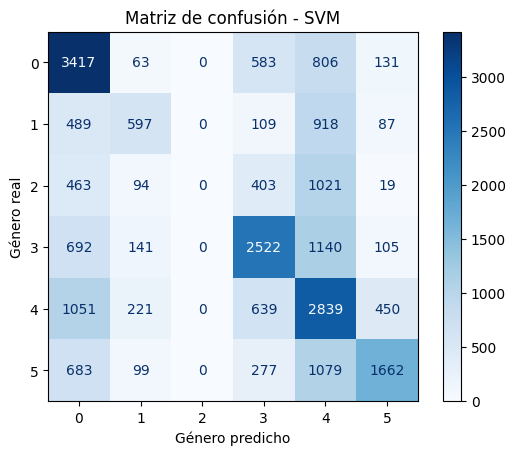

<Figure size 1200x1200 with 0 Axes>

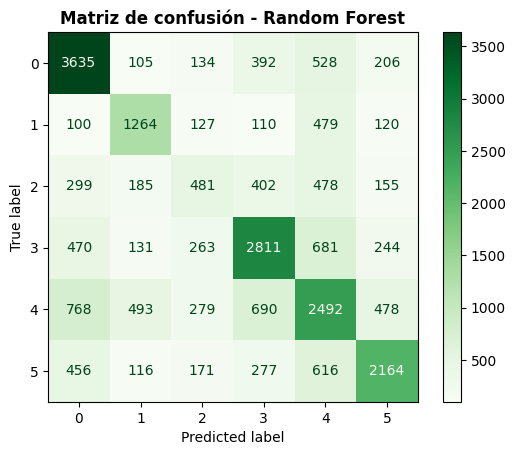

In [50]:
# Apartado 10.5
# Matriz de confusión - SVM

matriz_svm = confusion_matrix(y_test_class, pred_svm)

plt.figure(figsize=(12,12))
disp_svm = ConfusionMatrixDisplay(confusion_matrix=matriz_svm)
disp_svm.plot(cmap="Blues")
plt.title("Matriz de confusión - SVM")
disp_svm.ax_.set_xlabel("Género predicho")
disp_svm.ax_.set_ylabel("Género real")
plt.show()

# Matriz de confusión - Random Forest
matriz_rf = confusion_matrix(y_test_class, pred_rf_class)

plt.figure(figsize=(12,12))
disp_rf = ConfusionMatrixDisplay(confusion_matrix=matriz_rf)
disp_rf.plot(cmap="Greens")
plt.title("Matriz de confusión - Random Forest", fontweight='bold')
disp_svm.ax_.set_xlabel("Género predicho")
disp_svm.ax_.set_ylabel("Género real")
plt.show()

In [ ]:
# Apartado 10.6


### Apartado 10.6
Sí, en las matrices de confusión se puede observar que algunos géneros musicales se confunden más entre sí que otros.

Creo que esto ocurre porque muchos géneros comparten características musicales parecidas, como el ritmo, la energía o el tempo, por lo que al modelo le cuesta diferenciarlos correctamente.

Además, he podido comprobarlo visualizando las métricas en un gráfico de barras, donde se observa que Random Forest obtiene mejores resultados que SVM en la mayoría de métricas y muestra una clasificación más equilibrada entre los distintos géneros.

In [61]:
# Apartado 10.7

param_grid = {
  'n_estimators': [10, 50, 100],
  'max_depth': [None, 10, 20],
  'min_samples_split': [2, 5, 10],
  'criterion': ["gini", "entropy"]
}

# Modelo Random Forest
modelo_rf_grid = RandomForestClassifier(random_state=74)

# GridSearchCV
# Buscador automático de mejores parámetros para Random Forest
grid_search = GridSearchCV(estimator=modelo_rf_grid, param_grid=param_grid, scoring="f1_macro", cv=5, n_jobs=-1)

# Entrenamiento
grid_search.fit(X_train_class, y_train_class)

# Parámetros obtenidos
print("Mejores parámetros encontrados:")
print(grid_search.best_params_)


KeyboardInterrupt: 

In [30]:
# Apartado 10.8

# Entrenar GridSearch
grid_search.fit(X_train_class, y_train_class)

# Mejor modelo encontrado
mejor_modelo = grid_search.best_estimator_

# Predicciones
pred_best = mejor_modelo.predict(X_test_class)

# Probabilidades / confianza
probabilidades = mejor_modelo.predict_proba(X_test_class)

# Classification report
reporte = classification_report(y_test_class, pred_best, output_dict=True)

resultados = pd.DataFrame({
  "Clase": mejor_modelo.classes_,
  "F1-score": [
    reporte[clase]["f1-score"]
      for clase in mejor_modelo.classes_
    ],
    "Confianza media": np.mean(
        probabilidades,
        axis=0
    )
})

print(resultados)

NameError: name 'grid_search' is not defined

### Apartado 10.9
### Propón alguna mejora para mejorar el rendimiento de la clasificación.

Creo que una posible mejora sería probar más configuraciones en los modelos, ajustando mejor los parámetros para intentar conseguir una clasificación más precisa. También podría ayudar utilizar más datos o añadir nuevas variables que permitan diferenciar mejor los géneros musicales.

## Fase 5: Pipeline de Preprocesamiento (Clase Propia)

### Apartado 11: Encapsulamiento en una clase

11.1. Crear una clase llamada SpotifyPredictor que permita cargar un modelo ya entrenado. La clase debe incluir un método llamado predecir_exito que reciba un diccionario con las características de una canción nueva y devuelva el género estimado y su popularidad prevista.


In [76]:

class SpotifyPredictor:

  # Constructor usando modelos ya entrenados
  def __init__(self, modelo_genero, modelo_popularidad, scaler):
    self.modelo_genero = modelo_genero
    self.modelo_popularidad = modelo_popularidad
    self.scaler = scaler

  def predecir_exito(self, cancion_dict):

    # Convertir diccionario a DataFrame
    nueva_cancion =  pd.DataFrame([cancion_dict])

    # Ordenar columnas igual que en entrenamiento
    nueva_cancion = nueva_cancion[X_train.columns]

    # Escalar variables numéricas entre 0 a 1
    nueva_cancion[numeric_cols] = self.scaler.transform(
    nueva_cancion[numeric_cols])

    # Predicción de género
    genero_predicho = self.modelo_genero.predict(nueva_cancion)[0]

    # Predicción de popularidad
    popularidad_predicha = self.modelo_popularidad.predict(
      nueva_cancion)[0]

    return {
      "género_estimado": genero_predicho,
      "popularidad_prevista": round(popularidad_predicha, 2)
    }


##########################################
# Probador
#########################################

# Crear predictor
predictor = SpotifyPredictor(
    modelo_genero=modelo_rf_class,
    modelo_popularidad=modelo_rf,
    scaler=scaler
)

# Nueva canción y sus caracteristicas, Variables predictoras (X)
nueva_cancion = {
    "duration_ms": 210000,
    "danceability": 0.75,
    "energy": 0.80,
    "key": 5,
    "loudness": -5.2,
    "mode": 1,
    "speechiness": 0.05,
    "acousticness": 0.12,
    "instrumentalness": 0.0,
    "liveness": 0.15,
    "valence": 0.82,
    "tempo": 120.0,
    "time_signature": 4,
    "explicit": 1
}

# Predicción
resultado = predictor.predecir_exito(nueva_cancion)

print("Nueva cancion:", resultado)



Nueva cancion: {'género_estimado': 'traditional_roots', 'popularidad_prevista': np.float64(33.66)}


### Nota:


Durante la realización de la tarea tuve algunas dificultades al ejecutar algunas partes del código, especialmente en los apartados relacionados con el entrenamiento y validación de modelos.

Creo que esto se debe principalmente al tamaño del dataset, ya que contiene más de 114.000 registros, lo que hacía que algunos procesos tardaran bastante tiempo en ejecutarse o consumieran bastantes recursos.

Aun así, intenté optimizar algunas partes reduciendo muestras y ajustando algunos parámetros para poder seguir realizando pruebas y comparar correctamente los modelos.

Además, en algunos apartados decidí representar los resultados utilizando gráficos con Matplotlib, ya que me ayudó a entender mejor el comportamiento de los modelos y visualizar los resultados de una forma más clara.